In [ ]:
#!/usr/bin/env python
# coding: utf-8
"""Organized Ellipse_fit pipeline for SDSS r-band imaging.

Two intended uses:
1. Notebook version: step-by-step diagnostics and plotting.
2. Python version: sequential terminal run on gravity.

Edit only the "0. User inputs" block for a normal run.
"""



In [1]:
import sys
import pafit

print("Notebook Python:", sys.executable)
print("pafit path:", pafit.__file__)

Notebook Python: /home/huaijin/software/miniconda3/envs/tw_env/bin/python
pafit path: /home/huaijin/software/miniconda3/envs/tw_env/lib/python3.9/site-packages/pafit/__init__.py


# Ellipse_fit organized pipeline
This script/notebook measures photometric bar/disk parameters from an SDSS r-band corrected frame.
It is designed to run before `PA_DISK` and writes:
- `CACHE_ROOT/ellipse/ellipse_<plateifu>.json`
- `CACHE_ROOT/master_table.csv`



In [3]:
from pathlib import Path
import os
%config InlineBackend.figure_formats = ['svg']
# ---------- project/cache paths ----------
PROJECT_ROOT = Path(os.environ.get("TW_PROJECT_ROOT", "/home/huaijin/TW_external")).expanduser()
CACHE_ROOT = Path(os.environ.get("TW_CACHE_ROOT", str(PROJECT_ROOT / "intermediate_cache"))).expanduser()
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
FIG_DIR = CACHE_ROOT / "ellipse_figures"
SDSS_IMAGE_DIR = PROJECT_ROOT / "sdss_rband_frames"
MASTER_CSV = CACHE_ROOT / "master_table.csv"

for _d in [CACHE_ROOT, ELLIPSE_DIR, FIG_DIR, SDSS_IMAGE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ---------- MaNGA DRPall / effective radius / Ciutout size ----------
# Recommended Re source for MaNGA: DRPall column NSA_ELPETRO_TH50_R, in arcsec.
SAS_ROOT = Path(os.environ.get("SAS_BASE_DIR", "/home/huaijin/sas")).expanduser()
DRPALL_PATH = Path(os.environ.get(
    "DRPALL_PATH",
    str(SAS_ROOT / "dr17/manga/spectro/redux/v3_1_1/drpall-v3_1_1.fits")
)).expanduser()
RE_SOURCE = "drpall"             # "drpall" 
FALLBACK_RE_ARCSEC = True
CROP_RE_FACTOR = 8.0              # cutout side length = 8 * Re
SDSS_PIXEL_SCALE = 0.396          # arcsec/pixel for SDSS corrected frames
MIN_CUTOUT_PIX = 80
MAX_CUTOUT_PIX = 260              # safety cap for large galaxies; set None to disable

# ---------- SDSS frame download / local frame lookup ----------
# 推荐：先用 batch_download_sdss_rband_frames.ipynb 在登录节点批量下载好 frame。
# 这里 Ellipse_fit 只负责从 manifest 或 window_flist 自动找到对应 frame，不再访问 SkyServer。

AUTO_DOWNLOAD_SDSS_FRAME = False
SDSS_FRAME_NAME = "AUTO"          # "AUTO" means infer from plateifu automatically
FORCE_REDOWNLOAD = False

SDSS_MANIFEST_CSV = SDSS_IMAGE_DIR / "download_manifest.csv"
WINDOW_FLIST_PATH = PROJECT_ROOT / "sdss_aux/window_flist.fits"
# ---------- coordinate choice for cutout center ----------
# Fixed by design: always use OBJRA/OBJDEC from DRPall.
# Do not use FITS header CRVAL/CRPIX or manual coordinates as the galaxy center.
CENTER_SOURCE = "drpall"


In [19]:
# =========================================================
# 0. User inputs / run switches
# =========================================================
# ---------- target ----------
plateifu = "8724-12701"          # MaNGA plateifu used as the pipeline target ID
band = "r"                       # SDSS image band for ellipse fitting
# ---------- source detection / background ----------
SEP_DETECT_THRESH = 2.5
SEP_MINAREA = 8
SEP_BKG_BW = 200
SEP_BKG_BH = 200
SEP_BKG_FW = 1
SEP_BKG_FH = 1
TARGET_SELECTION = "nearest_center"  # "nearest_center" or "largest"
TARGET_PROTECT_RADIUS_FRAC = 0.30   # protect central region if main galaxy is not detected by SEP
USE_CUTOUT_CENTER_FOR_FIRST_ELLIPSE = True
USE_EXPANDED_OBJECT_MASK_WHEN_UNSEGMENTED = True
SEP_OBJECT_MASK_SCALE = 3.0          # only used when the central galaxy is not SEP-segmented
# ---------- first-pass ellipse fitting ----------
FIRST_SMA = 8.0
FIRST_EPS = 0.3
FIRST_PA_DEG = 150.0
FIRST_MINSMA = 1.0
FIRST_MAXSMA_PIX = 60.0
FIRST_STEP = 2.0
FIRST_CONVER = 0.03#0.01
FIRST_MAXGERR = 1.5
FIRST_MINIT = 20
FIRST_MAXIT = 100

# ---------- final ellipse fitting ----------
FINAL_SMA = 6.0
FINAL_EPS = 0.3
FINAL_PA_DEG = 150.0
FINAL_MINSMA = 1.0
# If FINAL_MAXSMA_PIX is None, use half the cutout side length minus a margin.
FINAL_MAXSMA_PIX = None
FINAL_STEP = 1.2
FINAL_CONVER = 0.02
FINAL_MAXGERR = 2.0
FINAL_MINIT = 20
FINAL_MAXIT = 50
FINAL_LINEAR = True

# ---------- bar/disk measurement settings ----------
PA_JUMP_THRESHOLD_DEG = 5.0   # Fixed
PA_STABLE_GRAD_DEG = 3.0     
A5_CONSECUTIVE_N = 3
Q0_INTRINSIC_DISK_THICKNESS = 0.2 # Fixed
WINDOW_DISK = 7
WINDOW_BAR = 4
PA_FLAT_DEG = 2.0
E_FLAT = 0.02
FOURIER_N_BINS = 50
FOURIER_SMOOTH_SIGMA = 1.0

# ---------- plotting / saving ----------
MAKE_PLOTS = True                 # notebook diagnostics
SAVE_FIGURES = True               # terminal-friendly output
SHOW_PLOTS = True                 # set False for batch terminal runs

# Keep the first cutout figure separate, but collect diagnostic figures
# 02--07 into one multi-panel PDF for easier batch inspection.
COMBINE_DIAGNOSTIC_PDF = True
DIAGNOSTIC_FIGURE_DPI = 160

print("plateifu        =", plateifu)
print("PROJECT_ROOT    =", PROJECT_ROOT)
print("CACHE_ROOT      =", CACHE_ROOT)
print("DRPALL_PATH     =", DRPALL_PATH)
print("CENTER_SOURCE   =", CENTER_SOURCE)
print("SDSS_FRAME_NAME =", SDSS_FRAME_NAME)



plateifu        = 8724-12701
PROJECT_ROOT    = /home/huaijin/TW_external
CACHE_ROOT      = /home/huaijin/TW_external/intermediate_cache
DRPALL_PATH     = /home/huaijin/sas/dr17/manga/spectro/redux/v3_1_1/drpall-v3_1_1.fits
CENTER_SOURCE   = drpall
SDSS_FRAME_NAME = frame-r-001350-3-0178


# 1. Imports and general utilities



In [5]:
# =========================================================
# 1. Imports and general utilities
# =========================================================
import json
import bz2
import shutil
import urllib.parse
import urllib.request
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.ma as ma

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales

from photutils.isophote import EllipseGeometry, Ellipse
from photutils.centroids import centroid_2dg

import sep
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import Ellipse as DrawEllipse


def ensure_dir(path):
    path = Path(path).expanduser()
    path.mkdir(parents=True, exist_ok=True)
    return path


DIAGNOSTIC_FIGURES = []
DIAGNOSTIC_FIGURE_TITLES = {
    "02": "SEP objects / target diagnostics",
    "03": "Masked image",
    "04": "First-pass ellipse fit",
    "05": "Final ellipse fit",
    "06": "Fourier bar/interbar contrast",
    "07": "Summary profiles",
}


def _capture_figure_as_image(fig, dpi=DIAGNOSTIC_FIGURE_DPI):
    """Render a Matplotlib figure to an RGB image array for PDF montage output."""
    import io
    import matplotlib.image as mpimg

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    buf.seek(0)
    img = mpimg.imread(buf)
    buf.close()
    return img


def _diagnostic_figure_key(path):
    """Return '02'...'07' for diagnostic figures that should be combined."""
    name = Path(path).name
    for key in DIAGNOSTIC_FIGURE_TITLES:
        if f"_{key}_" in name:
            return key
    return None


def savefig_maybe(fig, path, save=SAVE_FIGURES, show=SHOW_PLOTS, dpi=180):
    path = Path(path)

    # Collect figures 02--07 into a single PDF page rather than writing
    # six separate files. The initial cutout figure 01 is still saved
    # separately because it is often useful as a quick framing check.
    key = _diagnostic_figure_key(path)
    if save and COMBINE_DIAGNOSTIC_PDF and key is not None:
        img = _capture_figure_as_image(fig, dpi=DIAGNOSTIC_FIGURE_DPI)
        DIAGNOSTIC_FIGURES.append((key, DIAGNOSTIC_FIGURE_TITLES[key], img))
        print(f"Collected diagnostic figure {key} for combined PDF: {path.name}")
        if show:
            plt.show()
        else:
            plt.close(fig)
        return

    if save:
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure: {path}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def save_combined_diagnostic_pdf(output_path=None):
    """Save collected diagnostic figures 02--07 as one multi-panel PDF page."""
    if not (SAVE_FIGURES and COMBINE_DIAGNOSTIC_PDF):
        return None
    if len(DIAGNOSTIC_FIGURES) == 0:
        return None

    output_path = Path(output_path) if output_path is not None else FIG_DIR / f"{plateifu}_diagnostics_02_to_07.pdf"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # Keep only one copy per key, preserving the latest if a figure was regenerated.
    latest = {}
    for key, title, img in DIAGNOSTIC_FIGURES:
        latest[key] = (title, img)

    keys = [k for k in ["02", "03", "04", "05", "06", "07"] if k in latest]
    n = len(keys)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, key in zip(axes, keys):
        title, img = latest[key]
        ax.imshow(img)
        ax.set_title(f"{key}. {title}", fontsize=12)
        ax.axis("off")

    for ax in axes[len(keys):]:
        ax.axis("off")

    fig.suptitle(f"Ellipse-fit diagnostics: {plateifu}", fontsize=16, y=0.995)
    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(fig)
    print(f"Saved combined diagnostic PDF: {output_path}")
    return output_path


def get_col_case_insensitive(data, name):
    names = list(data.names)
    lut = {n.lower(): n for n in names}
    key = name.lower()
    if key not in lut:
        raise KeyError(f"Column {name!r} not found. Available columns include: {names[:20]} ...")
    return data[lut[key]]


def get_optional_col_case_insensitive(data, possible_names):
    for name in possible_names:
        try:
            return get_col_case_insensitive(data, name)
        except KeyError:
            pass
    return None


def angle_wrap_180(pa):
    return np.asarray(pa, dtype=float) % 180.0


def signed_axis_diff_deg(pa1, pa2):
    """Signed difference for 180-degree symmetric PA, returned in (-90, 90]."""
    d = (float(pa1) - float(pa2)) % 180.0
    if d > 90.0:
        d -= 180.0
    return d


def circular_mean_deg_180(pa_deg, w=None):
    """Circular mean for a 180-degree symmetric position angle."""
    pa = np.asarray(pa_deg, dtype=float)
    m = np.isfinite(pa)
    if w is None:
        w = np.ones_like(pa, dtype=float)
    else:
        w = np.asarray(w, dtype=float)
    m &= np.isfinite(w)
    if not np.any(m):
        return np.nan
    ang = np.deg2rad(2.0 * pa[m])
    x = np.nansum(w[m] * np.cos(ang))
    y = np.nansum(w[m] * np.sin(ang))
    return (0.5 * np.rad2deg(np.arctan2(y, x))) % 180.0


def inclination_from_ellipticity(e_disk, q0=0.2):
    """Thin/thick oblate disk inclination from ellipticity."""
    e_disk = float(e_disk)
    cos2i = ((1.0 - e_disk) ** 2 - q0**2) / (1.0 - q0**2)
    cos2i = np.clip(cos2i, 0.0, 1.0)
    return float(np.rad2deg(np.arccos(np.sqrt(cos2i))))



# 2. MaNGA metadata: RA/Dec and effective radius



In [6]:
# =========================================================
# 2. MaNGA metadata: RA/Dec and effective radius
# =========================================================
def load_manga_drpall_metadata(plateifu, drpall_path=DRPALL_PATH):
    """Read RA/Dec and Re from MaNGA DRPall.

    The key effective radius used here is NSA_ELPETRO_TH50_R in arcsec.
    It is the NSA elliptical Petrosian half-light radius in r band.
    """
    drpall_path = Path(drpall_path).expanduser()
    if not drpall_path.exists():
        raise FileNotFoundError(f"DRPall file not found: {drpall_path}")

    with fits.open(drpall_path) as hdul:
        data = hdul[1].data
        plateifu_col = get_col_case_insensitive(data, "plateifu").astype(str)
        idx = np.where(np.char.strip(plateifu_col) == str(plateifu))[0]
        if len(idx) == 0:
            raise KeyError(f"plateifu={plateifu} not found in {drpall_path}")
        row = data[idx[0]]
        names = {n.lower(): n for n in data.names}

        def value(name, default=np.nan):
            key = name.lower()
            return row[names[key]] if key in names else default

        ra = value("objra", value("ifura", np.nan))
        dec = value("objdec", value("ifudec", np.nan))
        re_arcsec = value("nsa_elpetro_th50_r", value("nsa_sersic_th50", np.nan))
        mangaid = value("mangaid", "")

    meta = {
        "plateifu": str(plateifu),
        "mangaid": str(mangaid).strip(),
        "ra_drpall_deg": float(ra),
        "dec_drpall_deg": float(dec),
        "Re_arcsec": float(re_arcsec),
        "Re_source": "DRPall:NSA_ELPETRO_TH50_R" if np.isfinite(re_arcsec) else "none",
    }
    return meta


def get_target_metadata():
    try:
        meta = load_manga_drpall_metadata(plateifu)
        print("Loaded MaNGA metadata from DRPall:", meta)
    except Exception as exc:
        print("[WARNING] Could not read DRPall metadata:", exc)
        meta = {
            "plateifu": plateifu,
            "mangaid": "",
            "ra_drpall_deg": np.nan,
            "dec_drpall_deg": np.nan,
            "Re_arcsec": np.nan,
            "Re_source": "none",
        }
    return meta

metadata = get_target_metadata()



Loaded MaNGA metadata from DRPall: {'plateifu': '8724-12701', 'mangaid': '1-47305', 'ra_drpall_deg': 130.335246061, 'dec_drpall_deg': 53.9386514555, 'Re_arcsec': 13.0768, 'Re_source': 'DRPall:NSA_ELPETRO_TH50_R'}


# 3. SDSS corrected-frame lookup and local-first download



In [7]:
# =========================================================
# 3. SDSS corrected-frame lookup and local-first download
# =========================================================
def frame_name_from_components(run, camcol, field, band="r"):
    return f"frame-{band}-{int(run):06d}-{int(camcol)}-{int(field):04d}"


def parse_frame_name(frame_name):
    stem = Path(frame_name).name
    stem = stem.replace(".fits.bz2", "").replace(".fits", "")
    parts = stem.split("-")
    if len(parts) != 5 or parts[0] != "frame":
        raise ValueError(f"Cannot parse SDSS frame name: {frame_name}")
    _, band_, run, camcol, field = parts
    return {"band": band_, "run": int(run), "camcol": int(camcol), "field": int(field)}

def strip_frame_suffix(name):
    """
    Convert:
        frame-r-003206-5-0020.fits.bz2
        frame-r-003206-5-0020.fits
        frame-r-003206-5-0020
    to:
        frame-r-003206-5-0020
    """
    stem = Path(str(name)).name
    stem = stem.replace(".fits.bz2", "")
    stem = stem.replace(".fits", "")
    return stem


def frame_name_from_components(run, camcol, field, band="r"):
    return f"frame-{band}-{int(run):06d}-{int(camcol)}-{int(field):04d}"


def auto_frame_name_from_manifest(
    plateifu,
    band="r",
    manifest_csv=SDSS_MANIFEST_CSV,
):
    """
    Read SDSS_FRAME_NAME from the batch-download manifest.

    Expected columns can include:
        plateifu, frame_filename, local_path, run, camcol, field, band
    """
    manifest_csv = Path(manifest_csv).expanduser()

    if not manifest_csv.exists():
        return None, None

    df = pd.read_csv(manifest_csv, dtype={"plateifu": str})
    if "plateifu" not in df.columns:
        return None, None

    hit = df[df["plateifu"].astype(str) == str(plateifu)]

    if "band" in df.columns:
        hit = hit[hit["band"].astype(str) == str(band)]

    if len(hit) == 0:
        return None, None

    row = hit.iloc[0]

    if "frame_filename" in row and pd.notna(row["frame_filename"]):
        frame_name = strip_frame_suffix(row["frame_filename"])
    elif all(col in row.index for col in ["run", "camcol", "field"]):
        frame_name = frame_name_from_components(
            row["run"],
            row["camcol"],
            row["field"],
            band=band,
        )
    elif "local_path" in row and pd.notna(row["local_path"]):
        frame_name = strip_frame_suffix(Path(row["local_path"]).name)
    else:
        return None, None

    return frame_name, row.to_dict()


def auto_frame_name_from_window_flist(
    plateifu,
    metadata,
    band="r",
    window_flist_path=WINDOW_FLIST_PATH,
):
    """
    Fallback method:
    plateifu -> DRPall RA/Dec -> local window_flist.fits -> nearest SDSS field.

    This does not use SkyServer.
    """
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    window_flist_path = Path(window_flist_path).expanduser()

    if not window_flist_path.exists():
        return None, None

    ra = float(metadata["ra_drpall_deg"])
    dec = float(metadata["dec_drpall_deg"])

    target = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    with fits.open(window_flist_path, memmap=True) as hdul:
        tab = hdul[1].data
        names_lower = {name.lower(): name for name in tab.names}

        ra_col = names_lower["ra"]
        dec_col = names_lower["dec"]
        run_col = names_lower["run"]
        camcol_col = names_lower["camcol"]
        field_col = names_lower["field"]

        coords = SkyCoord(
            ra=np.asarray(tab[ra_col], dtype=float) * u.deg,
            dec=np.asarray(tab[dec_col], dtype=float) * u.deg,
        )

        sep = target.separation(coords).arcmin
        best_idx = int(np.nanargmin(sep))
        row = tab[best_idx]

        run = int(row[run_col])
        camcol = int(row[camcol_col])
        field = int(row[field_col])
        sep_arcmin = float(sep[best_idx])

    frame_name = frame_name_from_components(run, camcol, field, band=band)

    info = {
        "plateifu": str(plateifu),
        "ra": ra,
        "dec": dec,
        "run": run,
        "camcol": camcol,
        "field": field,
        "band": band,
        "field_sep_arcmin": sep_arcmin,
        "source": "window_flist",
    }

    return frame_name, info


def decompress_bz2_if_needed(bz2_path, fits_path, force=False):
    bz2_path = Path(bz2_path).expanduser()
    fits_path = Path(fits_path).expanduser()

    if fits_path.exists() and fits_path.stat().st_size > 0 and not force:
        return fits_path

    import bz2
    import shutil

    print(f"Decompressing local bz2: {bz2_path} -> {fits_path}")

    with bz2.open(bz2_path, "rb") as f_in:
        with open(fits_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    return fits_path


def resolve_sdss_frame_path(metadata):
    """
    Resolve SDSS corrected frame locally.

    Priority:
    1. If SDSS_FRAME_NAME is manually specified, use it.
    2. If SDSS_FRAME_NAME == 'AUTO' or None, read from download_manifest.csv.
    3. If manifest is unavailable/missing target, use local window_flist.fits.
    4. Look for local .fits first, then local .fits.bz2 and decompress.
    5. No SkyServer query is used.
    """
    global SDSS_FRAME_NAME

    auto_info = None

    if SDSS_FRAME_NAME is None or str(SDSS_FRAME_NAME).upper() == "AUTO":
        frame_name, auto_info = auto_frame_name_from_manifest(
            plateifu=plateifu,
            band=band,
            manifest_csv=SDSS_MANIFEST_CSV,
        )

        if frame_name is not None:
            SDSS_FRAME_NAME = frame_name
            print(f"[INFO] Auto SDSS_FRAME_NAME from manifest: {SDSS_FRAME_NAME}")
        else:
            frame_name, auto_info = auto_frame_name_from_window_flist(
                plateifu=plateifu,
                metadata=metadata,
                band=band,
                window_flist_path=WINDOW_FLIST_PATH,
            )

            if frame_name is not None:
                SDSS_FRAME_NAME = frame_name
                print(f"[INFO] Auto SDSS_FRAME_NAME from window_flist: {SDSS_FRAME_NAME}")
            else:
                raise FileNotFoundError(
                    "Could not infer SDSS_FRAME_NAME automatically.\n"
                    f"Checked manifest: {SDSS_MANIFEST_CSV}\n"
                    f"Checked window_flist: {WINDOW_FLIST_PATH}\n"
                    "Please run batch_download_sdss_rband_frames.ipynb first, "
                    "or manually set SDSS_FRAME_NAME."
                )

    info = parse_frame_name(SDSS_FRAME_NAME)
    info["frame_name"] = frame_name_from_components(
        info["run"],
        info["camcol"],
        info["field"],
        band=info["band"],
    )

    fits_path = SDSS_IMAGE_DIR / f"{info['frame_name']}.fits"
    bz2_path = SDSS_IMAGE_DIR / f"{info['frame_name']}.fits.bz2"

    if fits_path.exists() and fits_path.stat().st_size > 0:
        print(f"[INFO] Using local FITS: {fits_path}")
    elif bz2_path.exists() and bz2_path.stat().st_size > 0:
        fits_path = decompress_bz2_if_needed(
            bz2_path=bz2_path,
            fits_path=fits_path,
            force=FORCE_REDOWNLOAD,
        )
    else:
        url = (
            f"http://data.sdss.org/sas/dr17/eboss/photoObj/frames/301/"
            f"{info['run']}/{info['camcol']}/{info['frame_name']}.fits.bz2"
        )

        if AUTO_DOWNLOAD_SDSS_FRAME:
            print("[INFO] Local frame not found. Downloading with wget:")
            print(url)

            import subprocess

            cmd = [
                "wget",
                "--tries=5",
                "--waitretry=5",
                "--timeout=60",
                "-O",
                str(bz2_path),
                url,
            ]
            subprocess.run(cmd, check=True)

            fits_path = decompress_bz2_if_needed(
                bz2_path=bz2_path,
                fits_path=fits_path,
                force=FORCE_REDOWNLOAD,
            )
        else:
            raise FileNotFoundError(
                f"Neither local FITS nor bz2 exists:\n"
                f"  {fits_path}\n"
                f"  {bz2_path}\n\n"
                f"You can download it manually on the login node with:\n"
                f"wget -O {bz2_path} {url}\n"
                f"bunzip2 -k {bz2_path}"
            )

    info["fits_path"] = str(fits_path)
    info["auto_info"] = auto_info

    return fits_path, info
    
fits_path, sdss_frame_info = resolve_sdss_frame_path(metadata)


[INFO] Auto SDSS_FRAME_NAME from manifest: frame-r-001350-3-0178
[INFO] Using local FITS: /home/huaijin/TW_external/sdss_rband_frames/frame-r-001350-3-0178.fits


# 4. Read FITS, choose center, and crop to 8 Re



the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


Original image shape: (1489, 2048)
Center source        : DRPall:OBJRA/OBJDEC
Center RA/Dec        : 130.335246061 53.9386514555
Full-frame pixel     : 1176.9290727026598 203.1342510943698
Re_arcsec            : 13.0768 from DRPall:NSA_ELPETRO_TH50_R
Pixel scale arcsec   : 0.3959869441660935
Cutout side pixels   : 260
Cutout shape         : (260, 260)
SPA from header = 40.326
Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_01_cutout.png


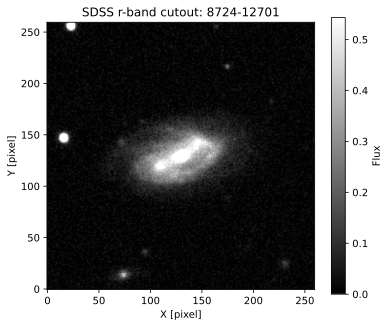

In [8]:
# =========================================================
# 4. Read FITS, choose center, and crop to 8 Re
# =========================================================
def choose_cutout_center(metadata):
    """Return the cutout center from DRPall OBJRA/OBJDEC only.

    Notes
    -----
    The FITS header CRVAL1/CRVAL2 are WCS reference coordinates, not necessarily
    the galaxy center. Manual coordinates are intentionally not supported here,
    so the pipeline center definition remains homogeneous for batch runs.
    """
    ra = metadata.get("ra_drpall_deg", np.nan)
    dec = metadata.get("dec_drpall_deg", np.nan)
    label = "DRPall:OBJRA/OBJDEC"

    if not np.isfinite(ra) or not np.isfinite(dec):
        raise ValueError(
            "DRPall OBJRA/OBJDEC are not finite; cannot define the cutout center. "
            f"Got RA={ra}, Dec={dec}."
        )
    return float(ra), float(dec), label


def compute_cutout_size_pixels(re_arcsec, pixel_scale_arcsec=SDSS_PIXEL_SCALE,
                               crop_re_factor=CROP_RE_FACTOR,
                               min_pix=MIN_CUTOUT_PIX,
                               max_pix=MAX_CUTOUT_PIX):
    """Cutout side length in pixels: side = crop_re_factor * Re_arcsec / pixel_scale."""
    side_pix = int(np.ceil(crop_re_factor * float(re_arcsec) / float(pixel_scale_arcsec)))
    side_pix = max(int(min_pix), side_pix)
    if max_pix is not None:
        side_pix = min(int(max_pix), side_pix)
    return side_pix


def load_and_crop_sdss_frame(fits_path, metadata):
    with fits.open(fits_path) as hdul:
        header = hdul[0].header.copy()
        image = hdul[0].data.astype(float)
    image[image < 0] = 0
    wcs = WCS(header)

    # Always use the MaNGA/NSA target position from DRPall as the cutout center.
    ra0, dec0, center_label = choose_cutout_center(metadata)
    x0_full, y0_full = wcs.wcs_world2pix(ra0, dec0, 0)

    pixscale = proj_plane_pixel_scales(wcs) * u.deg
    pixscale_arcsec_xy = pixscale.to(u.arcsec).value
    pixscale_arcsec = float(np.nanmean(np.abs(pixscale_arcsec_xy)))
    if not np.isfinite(pixscale_arcsec) or pixscale_arcsec <= 0:
        pixscale_arcsec = SDSS_PIXEL_SCALE

    side_pix = compute_cutout_size_pixels(metadata["Re_arcsec"], pixel_scale_arcsec=pixscale_arcsec)
    size = (side_pix, side_pix)

    position = SkyCoord(ra0, dec0, unit="deg")
    cutout = Cutout2D(
        image,
        position=position,
        size=size,
        wcs=wcs,
        mode="partial",
        fill_value=np.nan,
    )

    cut_data = cutout.data.astype(float)
    cut_wcs = cutout.wcs

    print("Original image shape:", image.shape)
    print("Center source        :", center_label)
    print("Center RA/Dec        :", ra0, dec0)
    print("Full-frame pixel     :", x0_full, y0_full)
    print("Re_arcsec            :", metadata["Re_arcsec"], "from", metadata["Re_source"])
    print("Pixel scale arcsec   :", pixscale_arcsec)
    print("Cutout side pixels   :", side_pix)
    print("Cutout shape         :", cut_data.shape)

    info = {
        "center_source": center_label,
        "center_ra_deg": ra0,
        "center_dec_deg": dec0,
        "x0_full_pix": float(x0_full),
        "y0_full_pix": float(y0_full),
        "pixel_scale_arcsec": pixscale_arcsec,
        "cutout_side_pix": int(side_pix),
    }
    return header, image, wcs, cut_data, cut_wcs, info

header, image, wcs, cut_data, cut_wcs, cutout_info = load_and_crop_sdss_frame(fits_path, metadata)
spa = header.get("SPA", 0.0)
if spa is None or not np.isfinite(spa):
    spa = 0.0
print("SPA from header =", spa)

if MAKE_PLOTS:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cut_data, origin="lower", cmap="gray",
                   vmin=np.nanpercentile(cut_data, 5),
                   vmax=np.nanpercentile(cut_data, 99.5))
    ax.set_title(f"SDSS {band}-band cutout: {plateifu}")
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    fig.colorbar(im, ax=ax, label="Flux")
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_01_cutout.png")


# 5. Background subtraction and source mask



Background globalback/globalrms: -2.7269543352304026e-06 1.0
Number of detected sources     : 2
Target selection reason        : main_galaxy_not_detected_by_SEP; masking detected sources outside central protected region
Target is segmented by SEP     : False
Target index/id                : 0 -1
Cutout center x/y              : 129.5 129.5
Central protect radius [pix]   : 78.0
Diagnostic SEP object x/y      : 15.743069018983979 146.92685956120778
Diagnostic object-center dist  : 115.08403355976755 pix
[WARNING] The selected diagnostic SEP object is not necessarily the galaxy. The ellipse fit should start from the cutout center.
Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_02_sep_objects.png


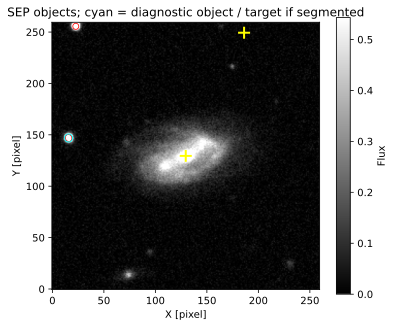

Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_03_masked.png


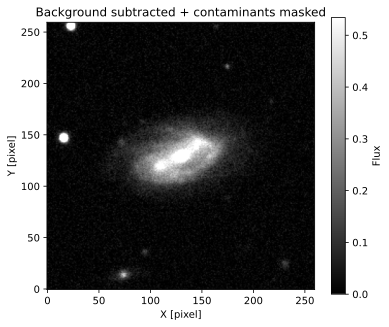

In [15]:
# =========================================================
# 5. Background subtraction and source mask
# =========================================================
def make_sep_object_ellipse_mask(
    shape,
    objects,
    keep_target_id=None,
    protect_mask=None,
    ellipse_scale=3.0,
):
    """
    Build an expanded ellipse mask for SEP-detected contaminating objects.

    This expanded mask is intentionally used only for the special case where
    the central galaxy is not detected as a SEP source. In the normal case
    where the central galaxy has a SEP label, the pipeline keeps the original
    segmentation-based masking behavior to avoid over-masking galaxy structure.
    """
    ny, nx = shape
    yy, xx = np.indices(shape)
    mask = np.zeros(shape, dtype=bool)

    for i, obj in enumerate(objects):
        obj_id = i + 1  # SEP segmentation labels are 1-based.

        if keep_target_id is not None and keep_target_id > 0 and obj_id == keep_target_id:
            continue

        x0 = float(obj["x"])
        y0 = float(obj["y"])
        a = float(obj["a"]) * float(ellipse_scale)
        b = float(obj["b"]) * float(ellipse_scale)
        theta = float(obj["theta"])

        if (not np.isfinite([x0, y0, a, b, theta]).all()) or a <= 0 or b <= 0:
            continue

        cos_t = np.cos(theta)
        sin_t = np.sin(theta)

        dx = xx - x0
        dy = yy - y0

        x_rot = dx * cos_t + dy * sin_t
        y_rot = -dx * sin_t + dy * cos_t

        obj_mask = (x_rot / a) ** 2 + (y_rot / b) ** 2 <= 1.0
        mask |= obj_mask

    if protect_mask is not None:
        mask &= ~protect_mask

    return mask


def build_background_and_segmentation(cut_data):
    data = np.asarray(cut_data, dtype=np.float64)
    data_for_sep = data.copy()
    data_for_sep[~np.isfinite(data_for_sep)] = 0.0

    bkg = sep.Background(
        data_for_sep,
        bw=SEP_BKG_BW, bh=SEP_BKG_BH,
        fw=SEP_BKG_FW, fh=SEP_BKG_FH,
    )

    data_sub = data_for_sep - bkg.back()
    data_sub[~np.isfinite(data)] = np.nan

    objects, segmap = sep.extract(
        np.nan_to_num(data_sub, nan=0.0),
        SEP_DETECT_THRESH,
        err=bkg.globalrms,
        minarea=SEP_MINAREA,
        segmentation_map=True,
    )

    if len(objects) == 0:
        raise RuntimeError("SEP detected no sources in the cutout.")

    ny, nx = data_sub.shape
    cy, cx = (np.array(data_sub.shape) - 1) / 2.0
    cy_int = int(round(cy))
    cx_int = int(round(cx))

    # ---------------------------------------------------------
    # 1. Try to identify the target from the segmentation label
    #    at / near the cutout center.
    # ---------------------------------------------------------
    target_id = 0
    target_index = None
    target_selection_reason = ""

    center_label = int(segmap[cy_int, cx_int]) if (0 <= cy_int < ny and 0 <= cx_int < nx) else 0

    if center_label > 0:
        target_id = center_label
        target_index = target_id - 1
        target_selection_reason = "segmap_label_at_cutout_center"

    # If exact center is not segmented, search a small central box.
    if target_id <= 0:
        r_search_pix = 5
        y0 = max(0, cy_int - r_search_pix)
        y1 = min(ny, cy_int + r_search_pix + 1)
        x0 = max(0, cx_int - r_search_pix)
        x1 = min(nx, cx_int + r_search_pix + 1)

        local_labels = segmap[y0:y1, x0:x1].ravel()
        local_labels = local_labels[local_labels > 0]

        if len(local_labels) > 0:
            labels, counts = np.unique(local_labels, return_counts=True)
            target_id = int(labels[np.argmax(counts)])
            target_index = target_id - 1
            target_selection_reason = f"most_common_segmap_label_within_{r_search_pix}px_of_center"

    # ---------------------------------------------------------
    # 2. Mask construction.
    #
    # Normal case:
    #   The galaxy has a SEP label at/near the cutout center.
    #   Use the conservative original segmentation-core mask:
    #       keep target_id and mask all other SEP labels.
    #
    # Special fallback case:
    #   The central galaxy is not detected by SEP, so ellipse fitting will
    #   start from the cutout center. In this case, use expanded object
    #   ellipse masks for detected sources outside the central protected
    #   region. This prevents small contaminating sources from remaining
    #   unmasked when the main galaxy itself is unsegmented.
    # ---------------------------------------------------------
    target_is_segmented = target_id > 0

    yy, xx = np.indices(data_sub.shape)
    r_center = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    protect_radius_pix = TARGET_PROTECT_RADIUS_FRAC * min(data_sub.shape)
    central_protect_mask = r_center <= protect_radius_pix

    if not target_is_segmented:
        target_selection_reason = (
            "main_galaxy_not_detected_by_SEP; "
            "using_cutout_center_for_ellipse; "
        )

        # Choose nearest object only for diagnostic plotting, not as the real galaxy target.
        dist2 = (objects["x"] - cx) ** 2 + (objects["y"] - cy) ** 2
        target_index = int(np.argmin(dist2))
        target_id = -1

        if USE_EXPANDED_OBJECT_MASK_WHEN_UNSEGMENTED:
            target_selection_reason += (
                "masking_expanded_SEP_object_ellipses_outside_central_protected_region"
            )
            star_mask = make_sep_object_ellipse_mask(
                data_sub.shape,
                objects,
                keep_target_id=None,
                protect_mask=central_protect_mask,
                ellipse_scale=SEP_OBJECT_MASK_SCALE,
            )
        else:
            target_selection_reason += (
                "masking_SEP_segmentation_pixels_outside_central_protected_region"
            )
            star_mask = (segmap != 0) & (~central_protect_mask)

    else:
        # Normal case: keep the central target label and mask all other detected sources.
        # This is the original conservative behavior and does not use expanded masks.
        star_mask = (segmap != 0) & (segmap != target_id)

    data_clean = data_sub.copy()
    data_clean[star_mask] = np.nan

    fit_data = ma.array(
        data_sub.copy(),
        mask=star_mask | ~np.isfinite(data_sub),
    )

    # ---------------------------------------------------------
    # Diagnostics
    # ---------------------------------------------------------
    print("Background globalback/globalrms:", bkg.globalback, bkg.globalrms)
    print("Number of detected sources     :", len(objects))
    print("Target selection reason        :", target_selection_reason)
    print("Target is segmented by SEP     :", target_is_segmented)
    print("Target index/id                :", target_index, target_id)
    print("Cutout center x/y              :", cx, cy)
    print("Central protect radius [pix]   :", protect_radius_pix)
    print("Expanded mask enabled          :", bool(USE_EXPANDED_OBJECT_MASK_WHEN_UNSEGMENTED and (not target_is_segmented)))
    print("SEP object mask scale          :", SEP_OBJECT_MASK_SCALE)
    print("Number of SEP-labeled pixels   :", int(np.sum(segmap != 0)))
    print("Number of masked pixels        :", int(np.sum(star_mask)))
    print("Masked fraction                :", float(np.sum(star_mask) / star_mask.size))

    if target_index is not None and 0 <= target_index < len(objects):
        target_dx = float(objects[target_index]["x"] - cx)
        target_dy = float(objects[target_index]["y"] - cy)
        target_dist = float(np.hypot(target_dx, target_dy))

        print("Diagnostic SEP object x/y      :", objects[target_index]["x"], objects[target_index]["y"])
        print("Diagnostic object-center dist  :", target_dist, "pix")

        if (not target_is_segmented) or target_dist > 0.15 * min(data_sub.shape):
            print(
                "[WARNING] The selected diagnostic SEP object is not necessarily the galaxy. "
                "The ellipse fit should start from the cutout center."
            )

    return data_sub, bkg, objects, segmap, target_index, target_id, star_mask, data_clean, fit_data

(data_sub, bkg, objects, segmap, target_index, target_id,
 star_mask, data_clean, fit_data) = build_background_and_segmentation(cut_data)

if MAKE_PLOTS:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(data_sub, origin="lower", cmap="gray",
                   vmin=np.nanpercentile(data_sub, 5),
                   vmax=np.nanpercentile(data_sub, 99.5))
    for i in range(len(objects)):
        e = DrawEllipse(
            xy=(objects["x"][i], objects["y"][i]),
            width=6 * objects["a"][i],
            height=6 * objects["b"][i],
            angle=objects["theta"][i] * 180.0 / np.pi,
            facecolor="none", edgecolor="red", lw=0.8,
        )
        ax.add_artist(e)
    if target_index is not None and 0 <= target_index < len(objects):
        ax.plot(objects["x"][target_index], objects["y"][target_index],
                "o", ms=8, mfc="none", mec="cyan",
                label="diagnostic SEP object")
    ax.set_title("SEP objects; cyan = diagnostic object / target if segmented")
    cy, cx = (np.array(data_sub.shape) - 1) / 2.0
    ax.plot(cx, cy, "+", ms=12, mew=2, color="yellow", label="cutout center")
    ax.legend(frameon=False, fontsize=8)
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    fig.colorbar(im, ax=ax, label="Flux")
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_02_sep_objects.png")

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(data_clean, origin="lower", cmap="gray",
                   vmin=np.nanpercentile(data_sub, 20),
                   vmax=np.nanpercentile(data_sub, 99.5))

    # Overlay actual masked regions for quick QA.
    if np.any(star_mask):
        ax.contour(star_mask.astype(int), levels=[0.5], colors="red", linewidths=0.8)

    cy, cx = (np.array(data_sub.shape) - 1) / 2.0
    ax.plot(cx, cy, "+", ms=12, mew=2, color="yellow")
    ax.set_title("Background subtracted + contaminants masked")
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    fig.colorbar(im, ax=ax, label="Flux")
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_03_masked.png")


In [18]:
print("data_sub min/median/max:", np.nanmin(data_sub), np.nanmedian(data_sub), np.nanmax(data_sub))
print("bkg.globalrms:", bkg.globalrms)
print("detect threshold absolute:", SEP_DETECT_THRESH * bkg.globalrms)

cy, cx = (np.array(data_sub.shape) - 1) / 2.0
r_test = 20
yy, xx = np.indices(data_sub.shape)
m = (xx - cx)**2 + (yy - cy)**2 < r_test**2
print("central mean/max:", np.nanmean(data_sub[m]), np.nanmax(data_sub[m]))
print("central seg labels:", np.unique(segmap[m])[:20])

data_sub min/median/max: -5.668486483045854e-05 0.005869522080502065 6.617149507968861
bkg.globalrms: 1.0
detect threshold absolute: 2.5
central mean/max: 0.43740478191142096 2.4335764362476766
central seg labels: [0]


# 6. First-pass ellipse fit: refine center



First-pass initial center: 129.5 129.5 (cutout_center)
First-pass fitted isophotes: 29
Refined center x0_avg/y0_avg: 129.85484846211335 129.25239273305758
Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_04_first_pass_ellipse.png


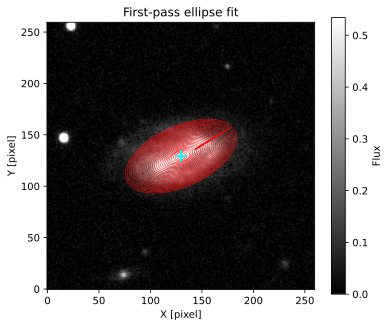

In [20]:
# =========================================================
# 6. First-pass ellipse fit: refine center
# =========================================================
def run_first_pass_ellipse(fit_data, objects, target_index):
    # In batch mode, the safest initial center is the cutout center,
    # because the cutout was centered on DRPall OBJRA/OBJDEC.
    cy0, cx0 = (np.array(fit_data.shape) - 1) / 2.0

    if USE_CUTOUT_CENTER_FOR_FIRST_ELLIPSE:
        x0_init = float(cx0)
        y0_init = float(cy0)
        center_reason = "cutout_center"
    else:
        if target_index is not None and 0 <= target_index < len(objects):
            x0_init = float(objects[target_index]["x"])
            y0_init = float(objects[target_index]["y"])
            center_reason = "SEP_target_centroid"
        else:
            x0_init = float(cx0)
            y0_init = float(cy0)
            center_reason = "cutout_center_fallback"

    print("First-pass initial center:", x0_init, y0_init, f"({center_reason})")

    geometry = EllipseGeometry(
        x0=x0_init,
        y0=y0_init,
        sma=FIRST_SMA,
        eps=FIRST_EPS,
        pa=np.deg2rad(FIRST_PA_DEG),
        fix_center=False,
        fix_pa=False,
        fix_eps=False,
    )

    ellipse = Ellipse(fit_data, geometry)

    isolist = ellipse.fit_image(
        minsma=FIRST_MINSMA,
        maxsma=FIRST_MAXSMA_PIX,
        step=FIRST_STEP,
        conver=FIRST_CONVER,
        maxgerr=FIRST_MAXGERR,
        minit=FIRST_MINIT,
        maxit=FIRST_MAXIT,
        linear=True,
    )

    print("First-pass fitted isophotes:", len(isolist))
    return isolist
    
isolist = run_first_pass_ellipse(fit_data, objects, target_index)

x0_list = np.array([iso.x0 for iso in isolist], dtype=float)
y0_list = np.array([iso.y0 for iso in isolist], dtype=float)
sma_list = np.array([iso.sma for iso in isolist], dtype=float)

# Robust center from inner fitted isophotes; fall back to 2D Gaussian centroid.
center_mask = np.isfinite(x0_list) & np.isfinite(y0_list) & (sma_list <= np.nanmedian(sma_list))
if np.sum(center_mask) >= 3:
    x0_avg = float(np.nanmedian(x0_list[center_mask]))
    y0_avg = float(np.nanmedian(y0_list[center_mask]))
else:
    try:
        y0_cent, x0_cent = centroid_2dg(fit_data)
        x0_avg, y0_avg = float(x0_cent), float(y0_cent)
    except Exception:
        x0_avg = float(objects[target_index]["x"])
        y0_avg = float(objects[target_index]["y"])

print("Refined center x0_avg/y0_avg:", x0_avg, y0_avg)

if MAKE_PLOTS:
    # Convert MaskedArray to a normal writable ndarray for plotting/statistics
    if np.ma.isMaskedArray(fit_data):
        plot_data = fit_data.filled(np.nan).astype(float)
    else:
        plot_data = np.asarray(fit_data, dtype=float).copy()

    plot_data = np.array(plot_data, dtype=float, copy=True)
    plot_data[~np.isfinite(plot_data)] = np.nan

    finite = np.isfinite(plot_data)
    if not np.any(finite):
        raise ValueError("No finite pixels available for plotting first-pass ellipse fit.")

    vmin, vmax = np.nanpercentile(plot_data[finite], [0, 99.5])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        plot_data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    for iso in isolist:
        x, y = iso.sampled_coordinates()
        ax.plot(x, y, color="red", lw=0.5)

    ax.plot(x0_avg, y0_avg, "+", color="cyan", ms=12, mew=2)
    ax.set_title("First-pass ellipse fit")
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    fig.colorbar(im, ax=ax, label="Flux")
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_04_first_pass_ellipse.png")

# 7. Final ellipse fit with fixed center



Final fitted isophotes: 104
Final maxsma_pix: 126.0
Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_05_final_ellipse.png


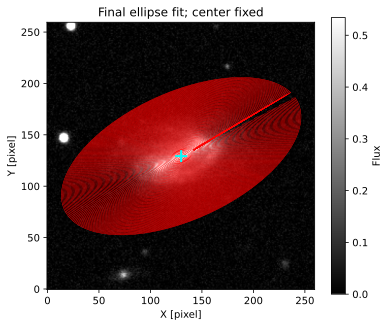

In [21]:
# =========================================================
# 7. Final ellipse fit with fixed center
# =========================================================
def run_final_ellipse(fit_data, x0_avg, y0_avg):
    maxsma = FINAL_MAXSMA_PIX
    if maxsma is None:
        maxsma = max(10.0, 0.5 * min(fit_data.shape) - 4.0)

    geometry2 = EllipseGeometry(
        x0=x0_avg,
        y0=y0_avg,
        sma=FINAL_SMA,
        eps=FINAL_EPS,
        pa=np.deg2rad(FINAL_PA_DEG),
        fix_center=True,
        fix_pa=False,
        fix_eps=False,
    )

    ellipse2 = Ellipse(fit_data, geometry2)
    isolist2 = ellipse2.fit_image(
        minsma=FINAL_MINSMA,
        maxsma=maxsma,
        step=FINAL_STEP,
        conver=FINAL_CONVER,
        maxgerr=FINAL_MAXGERR,
        minit=FINAL_MINIT,
        maxit=FINAL_MAXIT,
        linear=FINAL_LINEAR,
    )
    print("Final fitted isophotes:", len(isolist2))
    print("Final maxsma_pix:", maxsma)
    return isolist2, maxsma

isolist2, final_maxsma_used = run_final_ellipse(fit_data, x0_avg, y0_avg)


if MAKE_PLOTS:
    # Convert MaskedArray to a normal writable ndarray for plotting/statistics
    if np.ma.isMaskedArray(fit_data):
        plot_data = fit_data.filled(np.nan).astype(float)
    else:
        plot_data = np.asarray(fit_data, dtype=float).copy()

    # Force a writable copy; this avoids "output array is read-only" in np.nanpercentile
    plot_data = np.array(plot_data, dtype=float, copy=True)
    plot_data[~np.isfinite(plot_data)] = np.nan

    finite = np.isfinite(plot_data)
    if not np.any(finite):
        raise ValueError("No finite pixels available for plotting final ellipse fit.")

    vmin, vmax = np.nanpercentile(plot_data[finite], [0, 99.5])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        plot_data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    for iso in isolist2:
        x, y = iso.sampled_coordinates()
        ax.plot(x, y, color="red", lw=0.5)

    ax.plot(x0_avg, y0_avg, "+", color="cyan", ms=12, mew=2)
    ax.set_title("Final ellipse fit; center fixed")
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")
    fig.colorbar(im, ax=ax, label="Flux")
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_05_final_ellipse.png")

# 8. Extract radial profiles and preserve PA continuity treatment



In [22]:
# =========================================================
# 8. Extract radial profiles and preserve PA continuity treatment
# =========================================================
def extract_ellipse_profiles(isolist2, pixscale=SDSS_PIXEL_SCALE, spa=0.0):
    sma = np.array([iso.sma for iso in isolist2], dtype=float)
    intensity = np.array([iso.intens for iso in isolist2], dtype=float)
    int_err = np.array([iso.int_err for iso in isolist2], dtype=float)
    ellipticity = np.array([iso.eps for iso in isolist2], dtype=float)
    ellip_err = np.array([iso.ellip_err for iso in isolist2], dtype=float)
    pa = np.array([iso.pa for iso in isolist2], dtype=float)
    pa_err = np.array([iso.pa_err for iso in isolist2], dtype=float)

    sma_arcsec = sma * pixscale
    intensity_for_mu = intensity.copy()
    intensity_for_mu[intensity_for_mu <= 0] = np.nan

    area_pix = pixscale**2
    mu = 22.5 - 2.5 * np.log10(intensity_for_mu) + 2.5 * np.log10(area_pix)
    mu_err = (2.5 / np.log(10)) * (int_err / intensity_for_mu)

    # ---------------------------------------------------------
    # The user's requested PA treatment is intentionally preserved.
    # This makes the diagnostic PA profile continuous for plotting,
    # while respecting the 180-degree symmetry of ellipse PA.
    # ---------------------------------------------------------
    pa_deg = (np.rad2deg(pa) + spa + 90.0) % 180.0
    pa_deg_math = (np.rad2deg(pa) + spa) % 180.0
    pa_draw = pa_deg.copy()
    if len(pa_draw) >= 3 and np.all(np.isfinite(pa_draw[-3:])):
        pa_draw[np.where(pa_draw > np.mean(pa_draw[-3:]) + 5.0)] -= 180.0

    pa_err_deg = np.rad2deg(pa_err)

    return {
        "sma": sma,
        "sma_arcsec": sma_arcsec,
        "intensity": intensity,
        "int_err": int_err,
        "mu": mu,
        "mu_err": mu_err,
        "ellipticity": ellipticity,
        "ellip_err": ellip_err,
        "pa_rad": pa,
        "pa_err_rad": pa_err,
        "pa_deg": pa_deg,
        "pa_deg_math": pa_deg_math,
        "pa_draw": pa_draw,
        "pa_err_deg": pa_err_deg,
    }

profiles = extract_ellipse_profiles(isolist2, pixscale=cutout_info["pixel_scale_arcsec"], spa=spa)

sma = profiles["sma"]
sma_arcsec = profiles["sma_arcsec"]
mu = profiles["mu"]
mu_err = profiles["mu_err"]
ellipticity = profiles["ellipticity"]
ellip_err = profiles["ellip_err"]
pa_deg = profiles["pa_deg"]
pa_deg_math = profiles["pa_deg_math"]
pa_draw = profiles["pa_draw"]
pa_err_deg = profiles["pa_err_deg"]



# 9. Bar length estimates: amax and a5



In [23]:
# =========================================================
# 9. Bar length estimates: amax and a5
# =========================================================
def estimate_a_max_and_a5(sma_arcsec, ellipticity, pa_draw):
    dpa = np.abs(np.gradient(pa_draw))
    pa_stable = dpa < PA_STABLE_GRAD_DEG
    ellip_stable = ellipticity.copy()
    ellip_stable[~pa_stable] = np.nan

    if np.all(~np.isfinite(ellip_stable)):
        amax_index = int(np.nanargmax(ellipticity))
    else:
        amax_index = int(np.nanargmax(ellip_stable))

    e_bar = float(ellipticity[amax_index])
    PA_bar_draw = float(pa_draw[amax_index])
    a_max = float(sma_arcsec[amax_index])

    delta_pa = np.abs(pa_draw - PA_bar_draw)
    a5_index = None
    for i in range(amax_index + 1, len(sma_arcsec) - A5_CONSECUTIVE_N):
        if np.all(delta_pa[i:i + A5_CONSECUTIVE_N] > PA_JUMP_THRESHOLD_DEG):
            a5_index = i
            break
    a_5 = float(sma_arcsec[a5_index]) if a5_index is not None else np.nan

    return {
        "amax_index": amax_index,
        "a5_index": a5_index,
        "a_max": a_max,
        "a_5": a_5,
        "e_bar_at_amax": e_bar,
        "PA_bar_draw_at_amax": PA_bar_draw,
    }

bar_basic = estimate_a_max_and_a5(sma_arcsec, ellipticity, pa_draw)
a_max = bar_basic["a_max"]
a_5 = bar_basic["a_5"]
print("a_max =", a_max, "arcsec")
print("a_5   =", a_5, "arcsec")
print("e_bar at amax =", bar_basic["e_bar_at_amax"])
print("PA_bar_draw at amax =", bar_basic["PA_bar_draw_at_amax"])



a_max = 5.227027662992433 arcsec
a_5   = nan arcsec
e_bar at amax = 0.5049966218749075
PA_bar_draw at amax = 154.96517603805637


# 10. Disk/bar PA and ellipticity from flat radial regions



In [24]:
# =========================================================
# 10. Disk PA/ellipticity from flat outer region; bar PA/ellipticity at amax
# =========================================================
def find_flat_window(values, candidate_indices, window, tolerance):
    values = np.asarray(values, dtype=float)
    candidate_indices = np.asarray(candidate_indices, dtype=int)
    if len(candidate_indices) < window:
        return None
    for start in range(0, len(candidate_indices) - window + 1):
        idx = candidate_indices[start:start + window]
        vals = values[idx]
        if np.all(np.isfinite(vals)) and (np.nanmax(vals) - np.nanmin(vals) <= tolerance):
            return idx
    return None


def find_bar_disk_region(sma_arcsec, ellipticity, pa_draw, a_5,
                         window_disk=WINDOW_DISK, window_bar=WINDOW_BAR,
                         pa_flat_deg=PA_FLAT_DEG, e_flat=E_FLAT):
    """Find diagnostic bar/disk radial windows.

    The returned bar_indices are kept only for plotting/diagnostics. The adopted
    bar ellipticity and bar PA are taken strictly at amax, following the paper.
    """
    sma = np.asarray(sma_arcsec, dtype=float)
    e = np.asarray(ellipticity, dtype=float)
    pa = np.asarray(pa_draw, dtype=float)

    if not np.isfinite(a_5):
        a_5 = np.nanmedian(sma)

    bar_candidates = np.where((sma > 0.2 * a_5) & (sma < a_5))[0]
    disk_candidates = np.where(sma > a_5)[0]

    bar_idx = None
    for w in range(int(window_bar), 2, -1):
        bar_idx = find_flat_window(pa, bar_candidates, w, pa_flat_deg)
        if bar_idx is not None:
            break
    if bar_idx is None and len(bar_candidates) > 0:
        # Diagnostic fallback only: region around amax.
        i0 = max(0, bar_basic["amax_index"] - 1)
        i1 = min(len(sma), bar_basic["amax_index"] + 2)
        bar_idx = np.arange(i0, i1)

    disk_idx = None
    for w in range(int(window_disk), 2, -1):
        # Require both PA and ellipticity to be nearly flat in the outer disk.
        for start in range(0, len(disk_candidates) - w + 1):
            idx = disk_candidates[start:start + w]
            if (np.all(np.isfinite(pa[idx])) and np.all(np.isfinite(e[idx])) and
                (np.nanmax(pa[idx]) - np.nanmin(pa[idx]) <= pa_flat_deg) and
                (np.nanmax(e[idx]) - np.nanmin(e[idx]) <= e_flat)):
                disk_idx = idx
                break
        if disk_idx is not None:
            break
    if disk_idx is None and len(disk_candidates) > 0:
        disk_idx = disk_candidates[-min(len(disk_candidates), max(3, window_disk)):]

    return {"bar_indices": bar_idx, "disk_indices": disk_idx}


def estimate_bar_disk_params(sma_arcsec, ellipticity, pa_draw, a_5,
                             q0=Q0_INTRINSIC_DISK_THICKNESS,
                             ellip_err=None, pa_err_deg=None,
                             window_disk=WINDOW_DISK, window_bar=WINDOW_BAR,
                             pa_flat_deg=PA_FLAT_DEG, e_flat=E_FLAT):
    region = find_bar_disk_region(
        sma_arcsec, ellipticity, pa_draw, a_5,
        window_disk=window_disk, window_bar=window_bar,
        pa_flat_deg=pa_flat_deg, e_flat=e_flat,
    )
    disk_idx = region["disk_indices"]

    if disk_idx is None or len(disk_idx) == 0:
        raise RuntimeError("Could not identify a usable disk PA/ellipticity region.")

    # Paper-matched definition: e_bar and PA_bar are measured at amax.
    amax_index = int(bar_basic["amax_index"])
    e_bar = float(ellipticity[amax_index])
    PA_bar = float(pa_draw[amax_index] % 180.0)

    # Disk parameters are still measured from the outer flat region.
    e_disk = float(np.nanmean(ellipticity[disk_idx]))
    PA_disk = float(circular_mean_deg_180(pa_draw[disk_idx]))
    inc = inclination_from_ellipticity(e_disk, q0=q0)

    out = {
        **region,
        "amax_index": amax_index,
        "e_bar": e_bar,
        "e_disk": e_disk,
        "PA_bar_deg_0_180": PA_bar,
        "PA_disk_deg_0_180": PA_disk,
        "inclination_deg": inc,
        "bar_parameter_source": "at_amax",
    }
    return out

res = estimate_bar_disk_params(
    sma_arcsec=sma_arcsec,
    ellipticity=ellipticity,
    pa_draw=pa_draw,
    a_5=a_5,
    q0=Q0_INTRINSIC_DISK_THICKNESS,
    ellip_err=ellip_err,
    pa_err_deg=pa_err_deg,
    window_disk=WINDOW_DISK,
    window_bar=WINDOW_BAR,
    pa_flat_deg=PA_FLAT_DEG,
    e_flat=E_FLAT,
)

bar_indices = res["bar_indices"]
disk_indices = res["disk_indices"]
PA_bar = res["PA_bar_deg_0_180"]
PA_disk = res["PA_disk_deg_0_180"]
e_bar = res["e_bar"]
e_disk = res["e_disk"]
inc = res["inclination_deg"]

print("Bar diagnostic indices:", bar_indices)
print("Disk indices:", disk_indices)
print("amax index:", res["amax_index"])
print("PA_bar at amax  =", PA_bar)
print("PA_disk         =", PA_disk)
print("e_bar at amax   =", e_bar)
print("e_disk          =", e_disk)
print("inc             =", inc)


Bar diagnostic indices: [10 11 12 13]
Disk indices: [52 53 54 55 56 57 58]
amax index: 10
PA_bar at amax  = 154.96517603805637
PA_disk         = 154.96517603805637
e_bar at amax   = 0.5049966218749075
e_disk          = 0.5049966218749075
inc             = 62.47486868474487


# 11. Fourier bar length estimate af



Fourier search radius: r < 0.70 * maxsma
maxsma used for ellipse fitting : 49.89435496492778 arcsec
Fourier max radius              : 34.92604847544944 arcsec
Fourier Cmax search range: r < 0.30 * maxsma = 14.968306489478332 arcsec
Fourier Cmax at          : 1.7463024237724722 arcsec Cmax= 1.46329925171738
Fourier Cmin after peak  : 4.540386301808428 arcsec Cmin= 1.1220274921177555
Fourier threshold        : 1.2926633719175677
Fourier a_f crossing     : 2.9946919668091376 arcsec
a_f = 2.9946919668091376 arcsec
Saved figure: /home/huaijin/TW_external/intermediate_cache/ellipse_figures/8724-12701_06_fourier_contrast.png


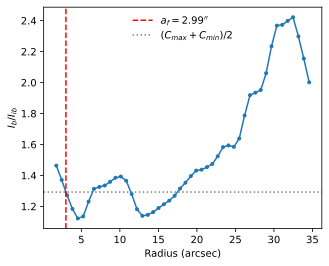

In [25]:
# =========================================================
# 11. Fourier bar length estimate af
# =========================================================
FOURIER_N_BINS = 50
FOURIER_SMOOTH_SIGMA = 1.0
FOURIER_MAXSMA_FRAC = 0.7
def elliptical_coordinates(shape, x0, y0, e_disk, PA_disk):
    ny, nx = shape
    y, x = np.indices((ny, nx))
    x = x - x0
    y = y - y0
    PA_rad = np.deg2rad(PA_disk)
    x_rot = x * np.cos(PA_rad) + y * np.sin(PA_rad)
    y_rot = -x * np.sin(PA_rad) + y * np.cos(PA_rad)
    q = max(1e-3, 1.0 - float(e_disk))
    r = np.sqrt(x_rot**2 + (y_rot / q)**2)
    theta = np.arctan2(y_rot / q, x_rot)
    return r, theta


def fourier_profile(data, r, theta, r_bins, PA_bar, m_list=(0, 2, 4, 6)):
    I_m = {m: [] for m in m_list}
    r_mid = []
    for i in range(len(r_bins) - 1):
        mask = (r >= r_bins[i]) & (r < r_bins[i + 1])
        values = data[mask]
        angles = theta[mask] - np.deg2rad(PA_bar)
        good = np.isfinite(values)
        values = values[good]
        angles = angles[good]
        if len(values) < 20:
            for m in m_list:
                I_m[m].append(np.nan)
            r_mid.append(np.nan)
            continue
        r_mid.append((r_bins[i] + r_bins[i + 1]) / 2.0)
        for m in m_list:
            if m == 0:
                I_m[m].append(np.nanmean(values))
            else:
                A_m = np.nanmean(values * np.cos(m * angles))
                B_m = np.nanmean(values * np.sin(m * angles))
                I_m[m].append(np.sqrt(A_m**2 + B_m**2))
    I0 = np.asarray(I_m[0], dtype=float)
    I2 = np.asarray(I_m[2], dtype=float)
    I4 = np.asarray(I_m[4], dtype=float)
    I6 = np.asarray(I_m[6], dtype=float)
    Ib = I0 + I2 + I4 + I6
    Iib = I0 - I2 + I4 - I6
    contrast = Ib / Iib
    return np.array(r_mid), {m: np.array(I_m[m]) for m in m_list}, contrast


def _interp_threshold_crossing(r1, c1, r2, c2, threshold):
    """Linear interpolation for c(r)=threshold between two adjacent bins."""
    if not np.isfinite([r1, c1, r2, c2, threshold]).all() or c2 == c1:
        return np.nan
    return float(r1 + (threshold - c1) * (r2 - r1) / (c2 - c1))

def compute_fourier_af_from_contrast(
    r_mid,
    contrast,
    a_5,
    pixel_scale,
    maxsma_pix=None,
    cmax_maxsma_frac=0.3,
):
    """Measure af from the bar/interbar contrast profile following the paper.

    The contrast is C(r)=Ib/Iib, with Ib=I0+I2+I4+I6 and
    Iib=I0-I2+I4-I6. The bar region is defined by

        C(r) > (Cmax - Cmin)/2 + Cmin = (Cmax + Cmin)/2.

    Modification:
    - Cmax is searched only within r < cmax_maxsma_frac * maxsma_pix.
    - The contrast profile itself is still computed over the original full range.
    - Cmin is still searched after the Cmax position, as before.
    - af is still the first post-peak outward crossing of the threshold.
    """
    r_mid = np.asarray(r_mid, dtype=float)
    contrast = np.asarray(contrast, dtype=float)

    finite = np.isfinite(r_mid) & np.isfinite(contrast) & (r_mid > 0)

    # Keep your original broad safety range if a_5 is available.
    if np.isfinite(a_5) and a_5 > 0:
        finite &= (r_mid < 2.0 * a_5 / pixel_scale)

    r = r_mid[finite]
    c = contrast[finite]

    if len(r) < 4:
        print("Not enough valid Fourier contrast points to measure a_f.")
        return np.nan, np.nan

    order = np.argsort(r)
    r = r[order]
    c = c[order]

    # ---------------------------------------------------------
    # New: restrict only the Cmax search to r < 0.3 * maxsma.
    # ---------------------------------------------------------
    if maxsma_pix is not None and np.isfinite(maxsma_pix) and maxsma_pix > 0:
        cmax_limit_pix = cmax_maxsma_frac * float(maxsma_pix)
        cmax_mask = r < cmax_limit_pix

        if np.sum(cmax_mask) < 2:
            print(
                "Not enough Fourier points inside "
                f"r < {cmax_maxsma_frac:.2f} * maxsma to find Cmax."
            )
            return np.nan, np.nan

        imax_candidates = np.where(cmax_mask)[0]
        imax = int(imax_candidates[np.nanargmax(c[imax_candidates])])

        print(
            "Fourier Cmax search range:",
            f"r < {cmax_maxsma_frac:.2f} * maxsma =",
            cmax_limit_pix * pixel_scale,
            "arcsec"
        )
    else:
        # Fallback to the original behavior if maxsma_pix is not provided.
        imax = int(np.nanargmax(c))

    r_peak = r[imax]
    cmax = c[imax]

    if imax >= len(r) - 2:
        print("Fourier contrast peak is too close to the outer boundary; cannot find post-peak minimum.")
        return np.nan, np.nan

    post = np.arange(imax + 1, len(r))
    imin = int(post[np.nanargmin(c[post])])
    r_min = r[imin]
    cmin = c[imin]

    threshold = 0.5 * (cmax + cmin)

    # The bar end is the first downward crossing after the contrast peak.
    af_pix = np.nan
    for j in range(imax, len(r) - 1):
        if (c[j] >= threshold and c[j + 1] <= threshold):
            af_pix = _interp_threshold_crossing(
                r[j], c[j],
                r[j + 1], c[j + 1],
                threshold
            )
            break

    if not np.isfinite(af_pix):
        # Fallback: closest post-peak point to the threshold.
        after_peak = np.arange(imax + 1, len(r))
        j = int(after_peak[np.nanargmin(np.abs(c[after_peak] - threshold))])
        af_pix = float(r[j])
        print("No explicit post-peak threshold crossing found; using closest post-peak point.")

    print("Fourier Cmax at          :", r_peak * pixel_scale, "arcsec", "Cmax=", cmax)
    print("Fourier Cmin after peak  :", r_min * pixel_scale, "arcsec", "Cmin=", cmin)
    print("Fourier threshold        :", threshold)
    print("Fourier a_f crossing     :", af_pix * pixel_scale, "arcsec")

    return af_pix, threshold
def fourier_bar_length(
    data, x0, y0, e_disk, PA_disk, PA_bar,
    pixel_scale,
    r_max_pix=None,
    n_bins=FOURIER_N_BINS,
    smooth_sigma=FOURIER_SMOOTH_SIGMA,
    maxsma_frac=FOURIER_MAXSMA_FRAC,
):
    """
    Fourier bar length measurement using only r < maxsma_frac * maxsma.

    Parameters
    ----------
    r_max_pix : float
        The reference maxsma in pixels, usually final_maxsma_used.
    maxsma_frac : float
        Fraction of maxsma used for Fourier contrast calculation and a_f search.
        For your requested setting, use 0.3.
    """
    if r_max_pix is None:
        r_max_pix = 0.5 * min(data.shape) - 2.0

    r_max_pix = float(r_max_pix)
    r_fourier_max_pix = maxsma_frac * r_max_pix

    print(f"Fourier search radius: r < {maxsma_frac:.2f} * maxsma")
    print("maxsma used for ellipse fitting :", r_max_pix * pixel_scale, "arcsec")
    print("Fourier max radius              :", r_fourier_max_pix * pixel_scale, "arcsec")

    r, theta = elliptical_coordinates(data.shape, x0, y0, e_disk, PA_disk)

    # Only build radial bins inside 0.3 * maxsma.
    r_bins = np.linspace(0, r_fourier_max_pix, n_bins + 1)

    r_mid, I_m, contrast = fourier_profile(
        data, r, theta, r_bins, PA_bar
    )

    if smooth_sigma is not None and smooth_sigma > 0:
        good = np.isfinite(contrast)
        contrast_s = contrast.copy()
        if np.sum(good) > 3:
            fill = np.interp(
                np.arange(len(contrast)),
                np.where(good)[0],
                contrast[good]
            )
            contrast_s = gaussian_filter1d(fill, smooth_sigma)
            contrast_s[~good] = np.nan
        contrast = contrast_s

    af_pix, threshold = compute_fourier_af_from_contrast(
    r_mid,
    contrast,
    a_5,
    pixel_scale,
    maxsma_pix=r_max_pix,
    cmax_maxsma_frac=0.3,
)

    a_f = af_pix * pixel_scale if np.isfinite(af_pix) else np.nan

    return r_mid * pixel_scale, contrast, a_f, threshold

def plot_contrast(r_arcsec, contrast, a_f, threshold):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(r_arcsec, contrast, "o-", ms=3)
    if np.isfinite(a_f):
        ax.axvline(a_f, color="red", ls="--", label=rf"$a_f={a_f:.2f}''$")
    if np.isfinite(threshold):
        ax.axhline(threshold, color="gray", ls=":", label=r"$(C_{max}+C_{min})/2$")
    ax.set_xlabel("Radius (arcsec)")
    ax.set_ylabel(r"$I_b/I_{ib}$")
    ax.legend(frameon=False)

    return fig, ax

# PA conversion for Fourier follows your original expression.
PA_disk_fourier = (PA_disk - spa - 90.0) % 180.0
PA_bar_fourier = (PA_bar - spa - 90.0) % 180.0
r_contrast_arcsec, contrast, a_f, threshold = fourier_bar_length(
    data_sub,
    x0_avg,
    y0_avg,
    e_disk,
    PA_disk_fourier,
    PA_bar_fourier,
    pixel_scale=cutout_info["pixel_scale_arcsec"],
    r_max_pix=final_maxsma_used,
    n_bins=FOURIER_N_BINS,
    smooth_sigma=FOURIER_SMOOTH_SIGMA,
    maxsma_frac=FOURIER_MAXSMA_FRAC,
)
print("a_f =", a_f, "arcsec")

if MAKE_PLOTS:
    fig, ax = plot_contrast(r_contrast_arcsec, contrast, a_f, threshold)
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_06_fourier_contrast.png")


# 12. Summary diagnostic profile plot



In [ ]:
# =========================================================
# 12. Summary diagnostic profile plot
# =========================================================
def unwrap_pa_180_profile(pa_deg, jump_threshold=50.0):
    """
    Unwrap a PA profile with 180-degree symmetry for plotting.

    If two adjacent finite points differ by more than jump_threshold degrees,
    try adding or subtracting 180 degrees to the current and all following
    points. Keep the correction if the new adjacent jump becomes smaller than
    jump_threshold.

    Parameters
    ----------
    pa_deg : array-like
        PA profile in degrees, usually in [0, 180).
    jump_threshold : float
        Jump threshold in degrees. Default is 50 deg.

    Returns
    -------
    pa_unwrapped : ndarray
        PA profile adjusted by cumulative +/-180 deg offsets for plotting.
    """
    pa = np.asarray(pa_deg, dtype=float)
    pa_unwrapped = pa.copy()

    offset = 0.0
    prev = np.nan

    for i in range(len(pa)):
        if not np.isfinite(pa[i]):
            pa_unwrapped[i] = np.nan
            continue

        current = pa[i] + offset

        if np.isfinite(prev):
            jump = current - prev

            if np.abs(jump) > jump_threshold:
                candidates = np.array([
                    current - 180.0,
                    current + 180.0,
                ])

                diffs = np.abs(candidates - prev)
                best = candidates[np.argmin(diffs)]
                best_diff = np.nanmin(diffs)

                if best_diff < jump_threshold:
                    offset += best - current
                    current = best

        pa_unwrapped[i] = current
        prev = current

    return pa_unwrapped
# =========================================================
# 12. Summary diagnostic profile plot
# =========================================================
def plot_profile_summary(
    sma_arcsec, mu, mu_err, ellipticity, ellip_err, pa_draw, pa_err_deg,
    a_max=None, a_5=None, a_f=None, res=None,
    pa_jump_threshold=50.0,
):
    fig, ax = plt.subplots(
        3, 1, figsize=(3.8, 6), sharex=True,
        gridspec_kw={"hspace": 0}
    )

    # ---------- unwrap PA only for plotting ----------
    pa_plot = unwrap_pa_180_profile(
        pa_draw,
        jump_threshold=pa_jump_threshold,
    )

    # ---------- surface brightness ----------
    ax[0].errorbar(
        sma_arcsec, mu, yerr=mu_err,
        fmt="o", ms=2,
        color="black", ecolor="gray",
        elinewidth=0.8, capsize=2,
    )
    ax[0].invert_yaxis()
    ax[0].set_ylabel(r"$\mu_r$ (mag arcsec$^{-2}$)")

    # ---------- ellipticity ----------
    ax[1].errorbar(
        sma_arcsec, ellipticity, yerr=ellip_err,
        fmt="o", ms=2,
        color="black", ecolor="gray",
        elinewidth=0.8, capsize=2,
    )
    ax[1].set_ylabel("Ellipticity")
    ax[1].set_ylim(0, max(0.95, np.nanmax(ellipticity) + 0.1))

    # ---------- PA, unwrapped for plotting ----------
    ax[2].errorbar(
        sma_arcsec, pa_plot, yerr=pa_err_deg,
        fmt="o", ms=2,
        color="black", ecolor="gray",
        elinewidth=0.8, capsize=2,
    )
    ax[2].set_ylabel("PA (deg)")
    ax[2].set_xlabel("Semi-major axis (arcsec)")

    # Optional: make PA y-limits compact around the plotted profile
    good_pa = np.isfinite(pa_plot)
    if np.any(good_pa):
        ymin = np.nanmin(pa_plot[good_pa]) - 10.0
        ymax = np.nanmax(pa_plot[good_pa]) + 10.0
        ax[2].set_ylim(ymin, ymax)

    # ---------- vertical markers ----------
    markers = [
        (a_max, "red", "a_max"),
        (a_5, "blue", "a_5"),
        (a_f, "green", "a_f"),
    ]

    for val, color, label in markers:
        if val is not None and np.isfinite(val):
            for a in ax:
                a.axvline(val, color=color, ls="--", lw=1.0)

            ax[0].text(
                val, ax[0].get_ylim()[0],
                label,
                color=color,
                rotation=90,
                va="bottom",
                ha="right",
                fontsize=8,
            )

    # ---------- highlight bar/disk selected regions ----------
    if res is not None:
        for idx, color in [
            (res.get("disk_indices"), "cyan"),
        ]:
            if idx is not None and len(idx) > 0:
                ax[1].plot(
                    sma_arcsec[idx], ellipticity[idx],
                    "s", color=color, ms=4, mfc="none",
                )
                ax[2].plot(
                    sma_arcsec[idx], pa_plot[idx],
                    "s", color=color, ms=4, mfc="none",
                )

    ax[0].tick_params(labelbottom=False)
    ax[1].tick_params(labelbottom=False)

    for a in ax:
        a.tick_params(direction="in", top=True, right=True)

    return fig, ax
if MAKE_PLOTS:
    fig, ax = plot_profile_summary(
        sma_arcsec, mu, mu_err, ellipticity, ellip_err, pa_draw, pa_err_deg,
        a_max=a_max, a_5=a_5, a_f=a_f, res=res,
    )
    savefig_maybe(fig, FIG_DIR / f"{plateifu}_07_profiles_summary.pdf")
    save_combined_diagnostic_pdf(FIG_DIR / f"{plateifu}_diagnostics_02_to_07.pdf")



In [ ]:
pa_draw

# 13. Save JSON and update master table


In [ ]:
# =========================================================
# 13. Save JSON and update master table
# =========================================================
def upsert_master_row(master_csv, row_dict, key="plateifu"):
    master_csv = Path(master_csv)

    if master_csv.exists():
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()

    row_df = pd.DataFrame([row_dict])

    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:
            df[key] = None

        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)

        # Add new columns to the existing table if needed.
        for col in row_df.columns:
            if col not in df.columns:
                df[col] = pd.NA

        # Add missing columns to the new row if needed.
        for col in df.columns:
            if col not in row_df.columns:
                row_df[col] = pd.NA

        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df


def _safe_float(value):
    """Convert value to float; return np.nan if conversion fails."""
    try:
        if value is None:
            return np.nan
        out = float(value)
        return out if np.isfinite(out) else np.nan
    except Exception:
        return np.nan


def save_ellipse_result(
    plateifu,
    sdss_frame_name,
    a_max,
    a_5,
    a_f,
    res,
    metadata,
    cutout_info,
    sdss_frame_info,
    outdir=ELLIPSE_DIR,
):
    """
    Save ellipse-fitting results.

    Notes
    -----
    In the updated notebook, the target center is fixed to DRPall OBJRA/OBJDEC.
    Therefore RA/Dec saved here should come from metadata, not from header CRVAL
    or manual variables.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # ---------- DRPall target coordinates ----------
    ra_drpall = _safe_float(metadata.get("ra_drpall_deg", np.nan))
    dec_drpall = _safe_float(metadata.get("dec_drpall_deg", np.nan))

    if not np.isfinite(ra_drpall) or not np.isfinite(dec_drpall):
        raise ValueError(
            "DRPall RA/Dec are not finite. "
            "Please check load_manga_drpall_metadata() and the DRPall file."
        )

    # ---------- photometric parameters ----------
    a_values = np.array([a_max, a_5, a_f], dtype=float)
    a_average = float(np.nanmean(a_values))

    e_disk = float(res["e_disk"])
    e_bar = float(res["e_bar"])
    PA_disk = float(res["PA_disk_deg_0_180"])
    PA_bar = float(res["PA_bar_deg_0_180"])
    inc = float(res["inclination_deg"])
    phi_bar_phot = signed_axis_diff_deg(PA_bar, PA_disk)

    payload = {
        # ---------- target / frame ----------
        "plateifu": str(plateifu),
        "mangaid": str(metadata.get("mangaid", "")),
        "ra_drpall_deg": ra_drpall,
        "dec_drpall_deg": dec_drpall,

        "sdss_frame_name": str(sdss_frame_name),
        "sdss_frame_url": sdss_frame_info.get("url", ""),
        "sdss_fits_path": sdss_frame_info.get("fits_path", ""),

        # ---------- cutout / image metadata ----------
        "Re_arcsec": float(metadata["Re_arcsec"]),
        "Re_source": str(metadata["Re_source"]),
        "crop_re_factor": float(CROP_RE_FACTOR),
        "cutout_side_pix": int(cutout_info["cutout_side_pix"]),
        "pixel_scale_arcsec": float(cutout_info["pixel_scale_arcsec"]),

        # In the updated notebook this should be "DRPall:OBJRA/OBJDEC".
        "center_source": str(cutout_info.get("center_source", "DRPall:OBJRA/OBJDEC")),
        "center_ra_deg": ra_drpall,
        "center_dec_deg": dec_drpall,

        # Ellipse-fitting center in the cutout image.
        "x0_cutout_pix": float(x0_avg),
        "y0_cutout_pix": float(y0_avg),

        # Header SPA is still useful for PA conversion diagnostics, but not as center.
        "SPA_header_deg": float(spa),

        # ---------- bar lengths ----------
        "a_max_arcsec": float(a_max),
        "a_5_arcsec": float(a_5),
        "a_f_arcsec": float(a_f),
        "a_average_arcsec": a_average,

        # ---------- bar / disk photometric parameters ----------
        # e_bar and PA_bar should now be the values at a_max.
        "e_bar": e_bar,
        "e_disk": e_disk,
        "PA_disk_phot_deg_0_180": PA_disk % 180.0,
        "PA_bar_deg_0_180": PA_bar % 180.0,
        "inclination_deg": inc,
        "phi_bar_phot_deg": phi_bar_phot,

        # ---------- diagnostic indices ----------
        "bar_indices": (
            None if res.get("bar_indices") is None
            else [int(i) for i in res["bar_indices"]]
        ),
        "disk_indices": (
            None if res.get("disk_indices") is None
            else [int(i) for i in res["disk_indices"]]
        ),

        "updated_at": datetime.now().isoformat(timespec="seconds"),
    }

    outfile = outdir / f"ellipse_{plateifu}.json"
    with open(outfile, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    print(f"Saved ellipse summary: {outfile}")
    return payload, outfile


ellipse_payload, ellipse_file = save_ellipse_result(
    plateifu=plateifu,
    sdss_frame_name=sdss_frame_info["frame_name"],
    a_max=a_max,
    a_5=a_5,
    a_f=a_f,
    res=res,
    metadata=metadata,
    cutout_info=cutout_info,
    sdss_frame_info=sdss_frame_info,
)


master_row = {
    # ---------- target ----------
    "plateifu": plateifu,
    "mangaid": ellipse_payload["mangaid"],

    # Use DRPall RA/Dec only.
    "RA": ellipse_payload["ra_drpall_deg"],
    "DEC": ellipse_payload["dec_drpall_deg"],
    "ra_drpall_deg": ellipse_payload["ra_drpall_deg"],
    "dec_drpall_deg": ellipse_payload["dec_drpall_deg"],

    # ---------- SDSS frame ----------
    "sdss_frame_name": ellipse_payload["sdss_frame_name"],
    "sdss_fits_path": ellipse_payload["sdss_fits_path"],

    # ---------- cutout ----------
    "Re_arcsec": ellipse_payload["Re_arcsec"],
    "Re_source": ellipse_payload["Re_source"],
    "cutout_side_pix": ellipse_payload["cutout_side_pix"],
    "pixel_scale_arcsec": ellipse_payload["pixel_scale_arcsec"],
    "center_source": ellipse_payload["center_source"],
    "center_ra_deg": ellipse_payload["center_ra_deg"],
    "center_dec_deg": ellipse_payload["center_dec_deg"],
    "x0_cutout_pix": ellipse_payload["x0_cutout_pix"],
    "y0_cutout_pix": ellipse_payload["y0_cutout_pix"],

    # ---------- photometric bar/disk parameters ----------
    "a_max_arcsec": ellipse_payload["a_max_arcsec"],
    "a_5_arcsec": ellipse_payload["a_5_arcsec"],
    "a_f_arcsec": ellipse_payload["a_f_arcsec"],
    "a_average_arcsec": ellipse_payload["a_average_arcsec"],
    "e_bar": ellipse_payload["e_bar"],
    "e_disk": ellipse_payload["e_disk"],
    "PA_disk_phot_deg_0_180": ellipse_payload["PA_disk_phot_deg_0_180"],
    "PA_bar_deg_0_180": ellipse_payload["PA_bar_deg_0_180"],
    "inclination_deg": ellipse_payload["inclination_deg"],
    "phi_bar_phot_deg": ellipse_payload["phi_bar_phot_deg"],

    # ---------- bookkeeping ----------
    "ellipse_json": str(ellipse_file),
    "ellipse_status": "done",
    "ellipse_updated_at": ellipse_payload["updated_at"],
}

upsert_master_row(MASTER_CSV, master_row, key="plateifu")


print("\nFinal Ellipse_fit summary")
print("-------------------------")
print(f"plateifu   = {ellipse_payload['plateifu']}")
print(f"RA, Dec    = {ellipse_payload['ra_drpall_deg']:.8f}, {ellipse_payload['dec_drpall_deg']:.8f} deg")
print(f"a_max      = {ellipse_payload['a_max_arcsec']:.3f} arcsec")
print(f"a_5        = {ellipse_payload['a_5_arcsec']:.3f} arcsec")
print(f"a_f        = {ellipse_payload['a_f_arcsec']:.3f} arcsec")
print(f"a_average  = {ellipse_payload['a_average_arcsec']:.3f} arcsec")
print(f"e_disk     = {ellipse_payload['e_disk']:.4f}")
print(f"e_bar      = {ellipse_payload['e_bar']:.4f}")
print(f"PA_disk    = {ellipse_payload['PA_disk_phot_deg_0_180']:.3f} deg")
print(f"PA_bar     = {ellipse_payload['PA_bar_deg_0_180']:.3f} deg")
print(f"inclination= {ellipse_payload['inclination_deg']:.3f} deg")
print(f"JSON       = {ellipse_file}")